# Porto Taxi Trajectory — Exploratory Data Analysis
TDT4225 Assignment 2, Part 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime, math, os
from dotenv import load_dotenv

load_dotenv()

PATH = os.getenv("PORTO_CSV_PATH")
CHUNKSIZE = 500_000


In [2]:
total_rows = 0
call_type_counts = {}
day_type_counts = {}
missing_data_counts = {}
taxi_trip_counts = {}
poly_len_hist = np.zeros(201, dtype=np.int64)
poly_len_stats = {"sum": 0, "sq_sum": 0, "min": None, "max": None, "empty": 0, "lt3": 0, "count": 0}
month_counts = {}
ts_min, ts_max = None, None
trip_id_seen = set()
dup_trip_id_rows = 0
origin_call_null_by_calltype = {}
origin_stand_null_by_calltype = {}

def poly_len(s):
    if not isinstance(s, str) or s == "[]":
        return 0
    return s.count("],[") + 1

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE)):
    total_rows += len(chunk)

    for col, counter in [("CALL_TYPE", call_type_counts), ("DAY_TYPE", day_type_counts), ("MISSING_DATA", missing_data_counts)]:
        vc = chunk[col].value_counts(dropna=False)
        for k, v in vc.items():
            counter[str(k)] = counter.get(str(k), 0) + int(v)

    vc_taxi = chunk["TAXI_ID"].value_counts()
    for tid, v in vc_taxi.items():
        taxi_trip_counts[tid] = taxi_trip_counts.get(tid, 0) + int(v)

    for ct in chunk["CALL_TYPE"].unique():
        sub = chunk[chunk["CALL_TYPE"] == ct]
        oc = origin_call_null_by_calltype.setdefault(ct, [0, 0])
        oc[0] += int(sub["ORIGIN_CALL"].isna().sum()); oc[1] += len(sub)
        os_ = origin_stand_null_by_calltype.setdefault(ct, [0, 0])
        os_[0] += int(sub["ORIGIN_STAND"].isna().sum()); os_[1] += len(sub)

    lens = chunk["POLYLINE"].apply(poly_len)
    poly_len_stats["count"] += len(lens)
    poly_len_stats["sum"] += int(lens.sum())
    poly_len_stats["sq_sum"] += int((lens**2).sum())
    cmin, cmax = int(lens.min()), int(lens.max())
    poly_len_stats["min"] = cmin if poly_len_stats["min"] is None else min(poly_len_stats["min"], cmin)
    poly_len_stats["max"] = cmax if poly_len_stats["max"] is None else max(poly_len_stats["max"], cmax)
    poly_len_stats["empty"] += int((lens == 0).sum())
    poly_len_stats["lt3"] += int((lens < 3).sum())

    clipped = lens.clip(upper=200)
    for v in clipped.value_counts().items():
        poly_len_hist[int(v[0])] += int(v[1])

    tmin, tmax = int(chunk["TIMESTAMP"].min()), int(chunk["TIMESTAMP"].max())
    ts_min = tmin if ts_min is None else min(ts_min, tmin)
    ts_max = tmax if ts_max is None else max(ts_max, tmax)

    months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))
    for m, v in months.value_counts().items():
        month_counts[m] = month_counts.get(m, 0) + int(v)

    for tid in chunk["TRIP_ID"].tolist():
        if tid in trip_id_seen:
            dup_trip_id_rows += 1
        else:
            trip_id_seen.add(tid)

    print(f"chunk {i} processed, rows so far: {total_rows}")

mean_len = poly_len_stats["sum"] / poly_len_stats["count"]
std_len = math.sqrt(poly_len_stats["sq_sum"] / poly_len_stats["count"] - mean_len**2)


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_81235/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 0 processed, rows so far: 500000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_81235/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 1 processed, rows so far: 1000000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_81235/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 2 processed, rows so far: 1500000


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_81235/3322267605.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.utcfromtimestamp(int(t)).strftime("%Y-%m"))


chunk 3 processed, rows so far: 1710670


In [3]:
print(f"Total rows: {total_rows}")
print(f"Unique taxis: {len(taxi_trip_counts)}")
print(f"Unique trip_ids: {len(trip_id_seen)}  (duplicate rows: {dup_trip_id_rows})")
print(f"CALL_TYPE: {call_type_counts}")
print(f"DAY_TYPE: {day_type_counts}")
print(f"MISSING_DATA: {missing_data_counts}")
print(f"Polyline length: mean={mean_len:.2f}, std={std_len:.2f}, min={poly_len_stats['min']}, max={poly_len_stats['max']}")
print(f"Empty polylines: {poly_len_stats['empty']}")
print(f"Trips with <3 points (invalid): {poly_len_stats['lt3']}")
print(f"Date range: {datetime.datetime.utcfromtimestamp(ts_min)} -> {datetime.datetime.utcfromtimestamp(ts_max)}")
print(f"ORIGIN_CALL null by call_type: {origin_call_null_by_calltype}")
print(f"ORIGIN_STAND null by call_type: {origin_stand_null_by_calltype}")


Total rows: 1710670
Unique taxis: 448
Unique trip_ids: 1710589  (duplicate rows: 81)
CALL_TYPE: {'B': 817881, 'C': 528019, 'A': 364770}
DAY_TYPE: {'A': 1710670}
MISSING_DATA: {'False': 1710660, 'True': 10}
Polyline length: mean=48.76, std=45.65, min=0, max=3881
Empty polylines: 5901
Trips with <3 points (invalid): 43904
Date range: 2013-07-01 00:00:53 -> 2014-06-30 23:59:56
ORIGIN_CALL null by call_type: {'C': [528019, 528019], 'B': [817881, 817881], 'A': [0, 364770]}
ORIGIN_STAND null by call_type: {'C': [528019, 528019], 'B': [11302, 817881], 'A': [364770, 364770]}


/var/folders/vw/s1y1tk491vs0wxp7cg76k3j80000gn/T/ipykernel_81235/180360124.py:10: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  print(f"Date range: {datetime.datetime.utcfromtimestamp(ts_min)} -> {datetime.datetime.utcfromtimestamp(ts_max)}")


In [32]:
day_type_counts = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["DAY_TYPE"]):
    vc = chunk["DAY_TYPE"].value_counts(dropna=False)
    for k, v in vc.items():
        day_type_counts[str(k)] = day_type_counts.get(str(k), 0) + int(v)

print(f"DAY_TYPE value counts: {day_type_counts}")
print(f"Number of distinct DAY_TYPE values: {len(day_type_counts)}")
print(f"Total rows: {sum(day_type_counts.values())}")
assert len(day_type_counts) == 1, "DAY_TYPE is not constant!"
print(f"All rows have DAY_TYPE = '{list(day_type_counts.keys())[0]}'")

DAY_TYPE value counts: {'A': 1710670}
Number of distinct DAY_TYPE values: 1
Total rows: 1710670
All rows have DAY_TYPE = 'A'


In [33]:
origin_call_null_by_calltype = {}
origin_stand_null_by_calltype = {}
call_type_totals = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["CALL_TYPE", "ORIGIN_CALL", "ORIGIN_STAND"]):
    for ct in chunk["CALL_TYPE"].unique():
        sub = chunk[chunk["CALL_TYPE"] == ct]
        call_type_totals[ct] = call_type_totals.get(ct, 0) + len(sub)

        oc = origin_call_null_by_calltype.setdefault(ct, [0, 0])
        oc[0] += int(sub["ORIGIN_CALL"].isna().sum())
        oc[1] += len(sub)

        os_ = origin_stand_null_by_calltype.setdefault(ct, [0, 0])
        os_[0] += int(sub["ORIGIN_STAND"].isna().sum())
        os_[1] += len(sub)

print("CALL_TYPE totals:", call_type_totals)
print("ORIGIN_CALL null counts by CALL_TYPE [null, total]:", origin_call_null_by_calltype)
print("ORIGIN_STAND null counts by CALL_TYPE [null, total]:", origin_stand_null_by_calltype)

# CALL_TYPE = A: ORIGIN_CALL should always be set (0 null), ORIGIN_STAND always NULL
a_call_null, a_call_total = origin_call_null_by_calltype["A"]
a_stand_null, a_stand_total = origin_stand_null_by_calltype["A"]
assert a_call_null == 0, "Expected ORIGIN_CALL always set for CALL_TYPE=A"
assert a_stand_null == a_stand_total, "Expected ORIGIN_STAND always NULL for CALL_TYPE=A"
print(f"CALL_TYPE=A: ORIGIN_CALL set for all {a_call_total} trips, ORIGIN_STAND NULL for all of them.")

# CALL_TYPE = C: both should always be NULL
c_call_null, c_call_total = origin_call_null_by_calltype["C"]
c_stand_null, c_stand_total = origin_stand_null_by_calltype["C"]
assert c_call_null == c_call_total, "Expected ORIGIN_CALL always NULL for CALL_TYPE=C"
assert c_stand_null == c_stand_total, "Expected ORIGIN_STAND always NULL for CALL_TYPE=C"
print(f"CALL_TYPE=C: both fields NULL for all {c_call_total} trips.")

# CALL_TYPE = B: ORIGIN_CALL always NULL, ORIGIN_STAND set for most but not all
b_call_null, b_call_total = origin_call_null_by_calltype["B"]
b_stand_null, b_stand_total = origin_stand_null_by_calltype["B"]
assert b_call_null == b_call_total, "Expected ORIGIN_CALL always NULL for CALL_TYPE=B"
b_stand_set = b_stand_total - b_stand_null
print(f"CALL_TYPE=B: ORIGIN_CALL NULL for all {b_call_total} trips.")
print(f"CALL_TYPE=B: ORIGIN_STAND set for {b_stand_set} / {b_stand_total} trips "
      f"({100*b_stand_set/b_stand_total:.1f}%), missing for {b_stand_null} "
      f"({100*b_stand_null/b_stand_total:.1f}%).")

CALL_TYPE totals: {'C': 528019, 'B': 817881, 'A': 364770}
ORIGIN_CALL null counts by CALL_TYPE [null, total]: {'C': [528019, 528019], 'B': [817881, 817881], 'A': [0, 364770]}
ORIGIN_STAND null counts by CALL_TYPE [null, total]: {'C': [528019, 528019], 'B': [11302, 817881], 'A': [364770, 364770]}
CALL_TYPE=A: ORIGIN_CALL set for all 364770 trips, ORIGIN_STAND NULL for all of them.
CALL_TYPE=C: both fields NULL for all 528019 trips.
CALL_TYPE=B: ORIGIN_CALL NULL for all 817881 trips.
CALL_TYPE=B: ORIGIN_STAND set for 806579 / 817881 trips (98.6%), missing for 11302 (1.4%).


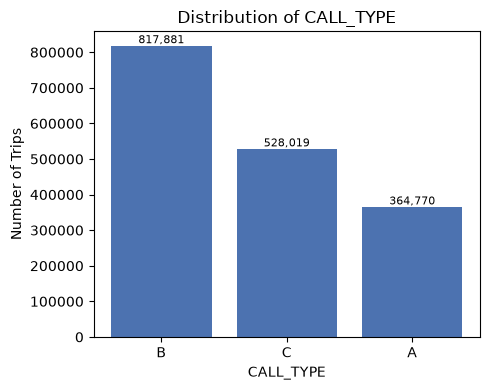

In [4]:
labels = list(call_type_counts.keys())
values = [call_type_counts[k] for k in labels]
plt.figure(figsize=(5,4))
plt.bar(labels, values, color="#4C72B0")
plt.title("Distribution of CALL_TYPE")
plt.xlabel("CALL_TYPE"); plt.ylabel("Number of Trips")
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("figures/call_type_dist.png", dpi=150)
plt.show()


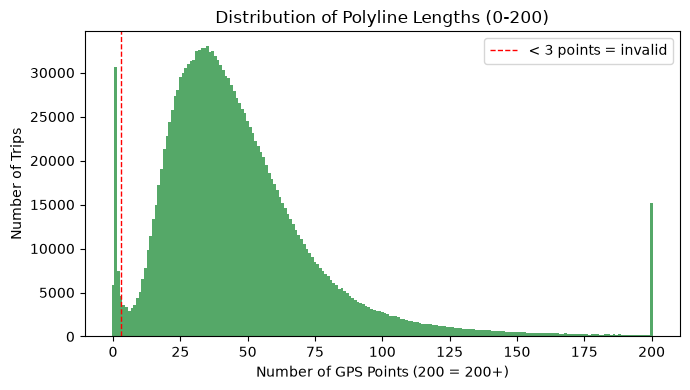

In [5]:
plt.figure(figsize=(7,4))
plt.bar(range(201), poly_len_hist, width=1.0, color="#55A868")
plt.title("Distribution of Polyline Lengths (0-200)")
plt.xlabel("Number of GPS Points (200 = 200+)"); plt.ylabel("Number of Trips")
plt.axvline(3, color="red", linestyle="--", linewidth=1, label="< 3 points = invalid")
plt.legend()
plt.tight_layout()
plt.savefig("figures/polyline_length_hist.png", dpi=150)
plt.show()


Taxi 20000080 share of its own trips that are short: 60.81%
Rest of fleet average share: 2.20%


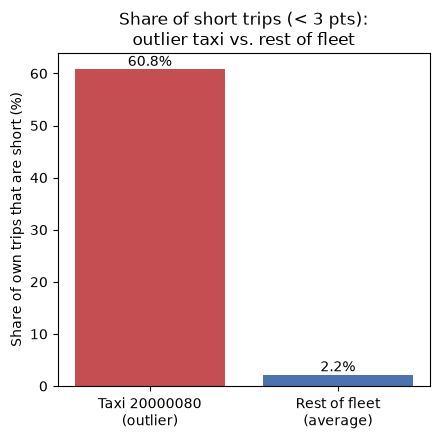

In [6]:
MIN_POINTS = 3  # invalid trip threshold from the assignment text

total_by_taxi = {}
short_by_taxi = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE):
    lens = chunk["POLYLINE"].apply(poly_len)
    vc_total = chunk["TAXI_ID"].value_counts()
    for tid, v in vc_total.items():
        total_by_taxi[tid] = total_by_taxi.get(tid, 0) + int(v)
    vc_short = chunk.loc[lens < MIN_POINTS, "TAXI_ID"].value_counts()
    for tid, v in vc_short.items():
        short_by_taxi[tid] = short_by_taxi.get(tid, 0) + int(v)

shares = {tid: short_by_taxi.get(tid, 0) / total_by_taxi[tid] for tid in total_by_taxi}

outlier_taxi_id, outlier_short_count = max(short_by_taxi.items(), key=lambda x: x[1])
outlier_share = shares[outlier_taxi_id]

rest_short = sum(short_by_taxi.values()) - outlier_short_count
rest_total = sum(total_by_taxi.values()) - total_by_taxi[outlier_taxi_id]
rest_share = rest_short / rest_total

print(f"Taxi {outlier_taxi_id} share of its own trips that are short: {outlier_share*100:.2f}%")
print(f"Rest of fleet average share: {rest_share*100:.2f}%")

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(4.5,4.5))
labels = [f"Taxi {outlier_taxi_id}\n(outlier)", "Rest of fleet\n(average)"]
values = [outlier_share * 100, rest_share * 100]
bars = plt.bar(labels, values, color=["#C44E52", "#4C72B0"])
plt.ylabel("Share of own trips that are short (%)")
plt.title(f"Share of short trips (< {MIN_POINTS} pts):\noutlier taxi vs. rest of fleet")
for b, v in zip(bars, values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("figures/outlier_taxi_share_comparison.png", dpi=150)
plt.show()

## Invalid trips: fewer than 3 GPS points

Following the assignment text, a trip is considered invalid if its polyline has fewer than
3 GPS points. This removes **43,904 trips (2.57%)**, leaving 1,666,766 trips (97.43%).

EDA of the distribution at low point counts revealed a strong, unnatural spike at exactly 1 point
(30,609 trips, compared to 5,901 with 0 points and 7,394 with 2 points). This
pattern is not explained by the `MISSING_DATA` flag (only 2 of the 30,609 are
flagged `True`), and it is strongly overrepresented for `CALL_TYPE = C`
(street hail, no prior verification) as well as concentrated on a single taxi
(`TAXI_ID = 20000080`, 17.3% of all 1-point trips, more than 3x the second highest).

**Interpretation**: These are most likely not real, short trips, but a combination
of (a) drivers activating the taximeter without an actual passenger
("test start"/accidental press), and (b) a systematic GPS/taximeter fault in
at least one specific vehicle that logs a single point before the connection
drops. Both interpretations point to noise in the data collection, not valid
observations of short taxi trips, which supports removing them.

Taxi 20000080 alone accounts for 6,535 of the invalid trips (14.9%), 2.6x the second
highest taxi (20000066, 2,497 trips). 60.8% of this taxi's own trips are invalid, compared
to an average of 2.2% for the rest of the fleet, which is consistent with a single faulty unit.

In [31]:
def poly_len(s):
    if not isinstance(s, str) or s == "[]":
        return 0
    return s.count("],[") + 1

MIN_POINTS = 3  # invalid trip threshold from the assignment text

invalid_by_taxi = {}
lens_len1 = {}
total = 0
invalid_count = 0
len1_count = 0

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE):
    lens = chunk["POLYLINE"].apply(poly_len)
    total += len(chunk)

    mask_invalid = lens < MIN_POINTS
    invalid_count += int(mask_invalid.sum())
    vc_invalid = chunk.loc[mask_invalid, "TAXI_ID"].value_counts()
    for tid, v in vc_invalid.items():
        invalid_by_taxi[tid] = invalid_by_taxi.get(tid, 0) + int(v)

    mask_len1 = lens == 1
    len1_count += int(mask_len1.sum())
    vc1 = chunk.loc[mask_len1, "TAXI_ID"].value_counts()
    for tid, v in vc1.items():
        lens_len1[tid] = lens_len1.get(tid, 0) + int(v)

print(f"Total trips: {total}")
print(f"Trips with < {MIN_POINTS} points (removed): {invalid_count} ({100*invalid_count/total:.2f}%)")
print(f"Trips remaining after cleaning: {total - invalid_count} ({100*(total-invalid_count)/total:.2f}%)")

top_taxis_invalid = sorted(invalid_by_taxi.items(), key=lambda x: -x[1])[:10]
print(f"\nTop 10 taxis contributing to <{MIN_POINTS}-point trips:")
for tid, cnt in top_taxis_invalid:
    print(f"  taxi {tid}: {cnt} trips")

top_taxi_id, top_taxi_count = top_taxis_invalid[0]
print(f"\nTaxi {top_taxi_id} alone: {top_taxi_count} trips "
      f"({100*top_taxi_count/invalid_count:.1f}% of all <{MIN_POINTS}-point trips)")

top_taxis_len1 = sorted(lens_len1.items(), key=lambda x: -x[1])[:5]
print(f"\nSame taxi's share of exact 1-point trips: "
      f"{lens_len1.get(top_taxi_id,0)} / {len1_count} "
      f"({100*lens_len1.get(top_taxi_id,0)/len1_count:.1f}%)")

Total trips: 1710670
Trips with < 3 points (removed): 43904 (2.57%)
Trips remaining after cleaning: 1666766 (97.43%)

Top 10 taxis contributing to <3-point trips:
  taxi 20000080: 6535 trips
  taxi 20000066: 2497 trips
  taxi 20000403: 1722 trips
  taxi 20000663: 995 trips
  taxi 20000196: 696 trips
  taxi 20000364: 551 trips
  taxi 20000286: 521 trips
  taxi 20000099: 512 trips
  taxi 20000167: 510 trips
  taxi 20000129: 508 trips

Taxi 20000080 alone: 6535 trips (14.9% of all <3-point trips)

Same taxi's share of exact 1-point trips: 5301 / 30609 (17.3%)


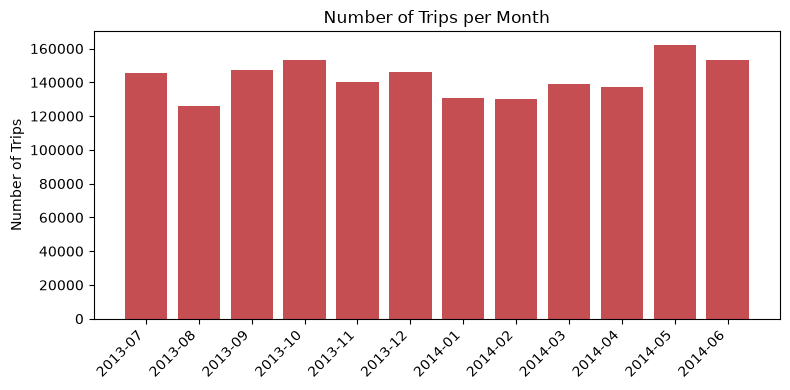

In [8]:
months_sorted = sorted(month_counts.keys())
plt.figure(figsize=(8,4))
plt.bar(months_sorted, [month_counts[m] for m in months_sorted], color="#C44E52")
plt.title("Number of Trips per Month")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("figures/trips_per_month.png", dpi=150)
plt.show()

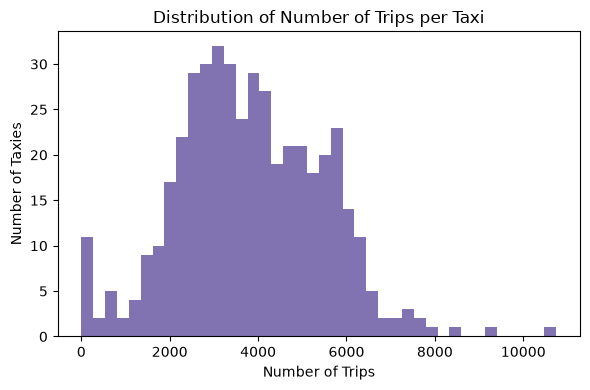

In [9]:
trip_counts_arr = np.array(list(taxi_trip_counts.values()))
plt.figure(figsize=(6,4))
plt.hist(trip_counts_arr, bins=40, color="#8172B2")
plt.title("Distribution of Number of Trips per Taxi")
plt.xlabel("Number of Trips"); plt.ylabel("Number of Taxies")
plt.tight_layout()
plt.savefig("figures/trips_per_taxi_hist.png", dpi=150)
plt.show()


## Duplicate TRIP_IDs
See separate investigation: 80 TRIP_ID values appear more than once (81 duplicate rows in total).
Cause: TRIP_ID is generated as TIMESTAMP + TAXI_ID, so two different trips by the same
taxi that start in the same second collide. 78 of the 80 groups are genuinely different trips
(different CALL_TYPE/POLYLINE), while 2 groups are exact duplicate rows.

In [10]:
seen_ids = set()
dup_ids = set()
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    vc = chunk["TRIP_ID"].value_counts()
    for tid, count in vc.items():
        if tid in seen_ids or count > 1:
            dup_ids.add(tid)
        seen_ids.add(tid)
print(f"Number of TRIP_IDs that appear >1 time: {len(dup_ids)}")


Number of TRIP_IDs that appear >1 time: 80


In [36]:
from collections import Counter

trip_id_counts = Counter()
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    for tid, c in chunk["TRIP_ID"].value_counts().items():
        trip_id_counts[tid] += c

dup_ids = {tid for tid, c in trip_id_counts.items() if c > 1}
group_sizes = Counter(trip_id_counts[tid] for tid in dup_ids)

print(f"TRIP_IDs occurring more than once: {len(dup_ids)}")
print(f"Group size distribution among duplicates: {dict(group_sizes)}")
print(f"Extra rows beyond one-per-ID: {sum(trip_id_counts[tid] - 1 for tid in dup_ids)}")

TRIP_IDs occurring more than once: 80
Group size distribution among duplicates: {2: 79, 3: 1}
Extra rows beyond one-per-ID: 81


In [37]:
dup_rows = {}
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    sub = chunk[chunk["TRIP_ID"].isin(dup_ids)]
    for _, row in sub.iterrows():
        dup_rows.setdefault(row["TRIP_ID"], []).append(tuple(row))

rows_to_drop = 0
genuine_collision_groups = 0

for tid, rows in dup_rows.items():
    distinct_rows = set(rows)
    rows_to_drop += len(rows) - len(distinct_rows)
    if len(distinct_rows) > 1:
        genuine_collision_groups += 1

print(f"Total duplicate TRIP_ID groups: {len(dup_rows)}")
print(f"Groups containing at least one genuinely different trip: {genuine_collision_groups}")
print(f"Exact-duplicate rows to drop during cleaning: {rows_to_drop}")

Total duplicate TRIP_ID groups: 80
Groups containing at least one genuinely different trip: 80
Exact-duplicate rows to drop during cleaning: 0
